# CASM voltage dumps: trigger, read, correlate

Everything below runs on **casm-corr1** with the offline venv as the kernel
(`/home/casm/software/dev/casm_venvs/casm_offline_env`).

The flow: dump a few seconds of raw voltages, gather all six streams into a
working directory of your choice, read them back (whole band or a subset of
sub-bands and SNAPs), and — if you need them — form visibilities at the native
32.768 microsecond sampling or any integration time.

Voltages are 4+4-bit complex, one byte per sample, 3072 channels over
390.6-484.4 MHz in six 512-channel streams (stream 0 is the top of the band).
One second of the full array is about 12.4 GB on disk.

## 1. Dump and gather

`dump_voltages(seconds, gather_dir)` triggers the dump daemons on both nodes,
waits for the files, pulls the casm-corr2 streams into your directory (the
casm-corr1 ones are symlinked — copy them if the directory has to outlive
`cand_dumps`), prints every gathered file, and returns what `VoltageReader`
needs. Skip this cell if you already have a dump.

In [1]:
from casm_t2.dump_client import dump_voltages

data_dir, prefix = dump_voltages(2, "~/voltage_dumps/quickstart")
data_dir, prefix

window   2026-07-31-00:08:54.102 .. 2026-07-31-00:08:56.102 (2.000 s)


stream 0  casm-corr1:27000 -> OK


stream 1  casm-corr1:27001 -> OK


stream 2  casm-corr1:27002 -> OK


stream 3  casm-corr2:27003 -> OK


...

gather   stream 0: 1 symlink(s) to local files
gather   stream 1: 1 symlink(s) to local files
gather   stream 2: 1 symlink(s) to local files
gather   stream 3: 1 file(s) from casm-corr2


gather   stream 4: 1 file(s) from casm-corr2


gather   stream 5: 1 file(s) from casm-corr2


gather   WARNING: stream(s) 0, 1, 2 are symlinks into /mnt/nvme4/data/casm/cand_dumps — deleting the originals breaks them; copy them over if /home/casm/voltage_dumps/quickstart has to stand on its own

gathered under /home/casm/voltage_dumps/quickstart/stream_N/ — read it with:
  VoltageReader('/home/casm/voltage_dumps/quickstart', '2026-07-29-21:06:34_0200763960274944')

gathered files:
  /home/casm/voltage_dumps/quickstart/stream_0/2026-07-29-21:06:34_0200763960274944.000000.dada
  /home/casm/voltage_dumps/quickstart/stream_1/2026-07-29-21:06:34_0200763960274944.000000.dada
  /home/casm/voltage_dumps/quickstart/stream_2/2026-07-29-21:06:34_0200763960274944.000000.dada
  /home/casm/voltage_dumps/quickstart/stream_3/2026-07-29-21:06:34_0200763960274944.000000.dada
  /home/casm/voltage_dumps/quickstart/stream_4/2026-07-29-21:06:34_0200763960274944.000000.dada
  /home/casm/voltage_dumps/quickstart/stream_5/2026-07-29-21:06:34_0200763960274944.000000.dada


('/home/casm/voltage_dumps/quickstart', '2026-07-29-21:06:34_0200763960274944')

## 2. Read voltages back

`VoltageReader(data_dir, prefix)` finds the streams. Reads take `seconds=` /
`offset_seconds=` (or exact sample counts via `n_time=` / `time_offset=`),
`subbands=` for a contiguous stream selection, and `snaps=` for a subset of
SNAP boards. The default return is the raw SNAP layout: a dict
`{snap: (n_time, n_chan, 12 ADCs)}`, complex64 with integer values -8..7.
Pass `antenna_csv=` to get one `(n_time, n_chan, n_ant)` array in CSV row
order instead.

In [2]:
from casm_io.voltage import VoltageReader

reader = VoltageReader(data_dir, prefix)
print("streams on disk:", reader.subbands_found)

res = reader.read_full_band(seconds=0.1, subbands=[1, 2], snaps=[0, 3],
                            verbose=False)
v0 = res.voltages[0]
print(f"SNAP 0: {v0.shape} {v0.dtype}   (time, channel, adc)")
print(f"freq: {res.freq_mhz[0]:.4f} -> {res.freq_mhz[-1]:.4f} MHz")
print(f"UTC start: {res.utc_start}")

streams on disk: [0, 1, 2, 3, 4, 5]


SNAP 0: (3052, 1024, 12) complex64   (time, channel, adc)
freq: 468.7500 -> 437.5305 MHz
UTC start: 2026-07-29-21:06:34


## 3. Long reads: gulp iteration

A full dump unpacked to complex64 is ~8x its disk size, so don't read minutes
in one call. `iter_full_band` yields RAM-sized chunks (the gulp defaults to a
fraction of the memory currently free); accumulate whatever you need across
them. Here: a bandpass.

In [3]:
import numpy as np

spec = {}          # snap -> (n_chan, n_adc) accumulated |v|^2
n = 0
for chunk in reader.iter_full_band(seconds=2, snaps=[0, 3]):
    for s, v in chunk.voltages.items():
        acc = np.sum(v.real**2 + v.imag**2, axis=0)
        spec[s] = spec.get(s, 0) + acc
    n += next(iter(chunk.voltages.values())).shape[0]

freq = chunk.freq_mhz
header = chunk.header
print(f"accumulated {n} samples ({n * 32.768e-6:.2f} s) "
      f"for SNAPs {sorted(spec)}")

accumulated 61035 samples (2.00 s) for SNAPs [0, 3]


## 4. Visibilities (optional)

`correlate()` multiplies the inputs pairwise and *then* averages — the order
matters, so the function owns it. `tint_s=None` keeps the native 32.768 us
resolution; any other integration time is rounded to whole samples. Dict
input is stacked in (snap, adc) order and the labels come back in
`.inputs`.

native: (153, 512, 24, 24) (bin, channel, input, input), tint = 1 sample
1 ms:   (4, 512, 24, 24) tint = 31 samples
input 0 is (snap, adc) = (0, 0) ... input 12 is (3, 0)


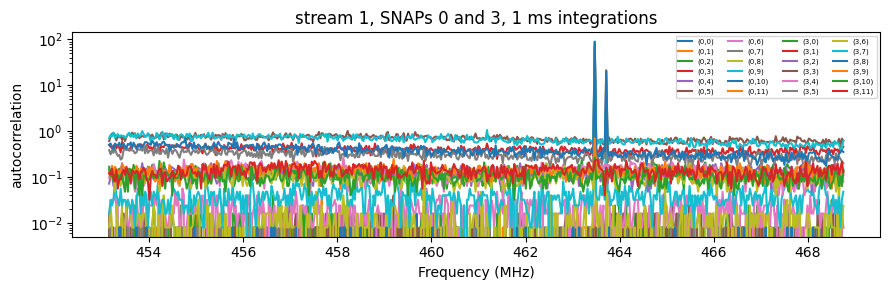

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
from casm_io.voltage import correlate

small = reader.read_full_band(seconds=0.005, subbands=[1], snaps=[0, 3],
                              verbose=False)

native = correlate(small.voltages)              # native 32.768 us resolution
avg = correlate(small.voltages, tint_s=0.001)   # 1 ms integrations

print("native:", native.vis.shape, "(bin, channel, input, input),",
      f"tint = {native.tint_samples} sample")
print("1 ms:  ", avg.vis.shape, f"tint = {avg.tint_samples} samples")
print("input 0 is (snap, adc) =", avg.inputs[0], "... input 12 is", avg.inputs[12])

auto = np.diagonal(avg.vis, axis1=2, axis2=3).real.mean(axis=0)
plt.figure(figsize=(9, 3))
plt.semilogy(small.freq_mhz, auto)
plt.xlabel("Frequency (MHz)")
plt.ylabel("autocorrelation")
plt.title("stream 1, SNAPs 0 and 3, 1 ms integrations")
plt.legend([f"({s},{a})" for s, a in avg.inputs], fontsize=5, ncol=4)
plt.tight_layout()

## 5. Autocorrelation bandpasses

The accumulated spectra from step 3, one figure per SNAP with every ADC
labelled; the title carries the local time range of the data (daylight
saving handled by zoneinfo).

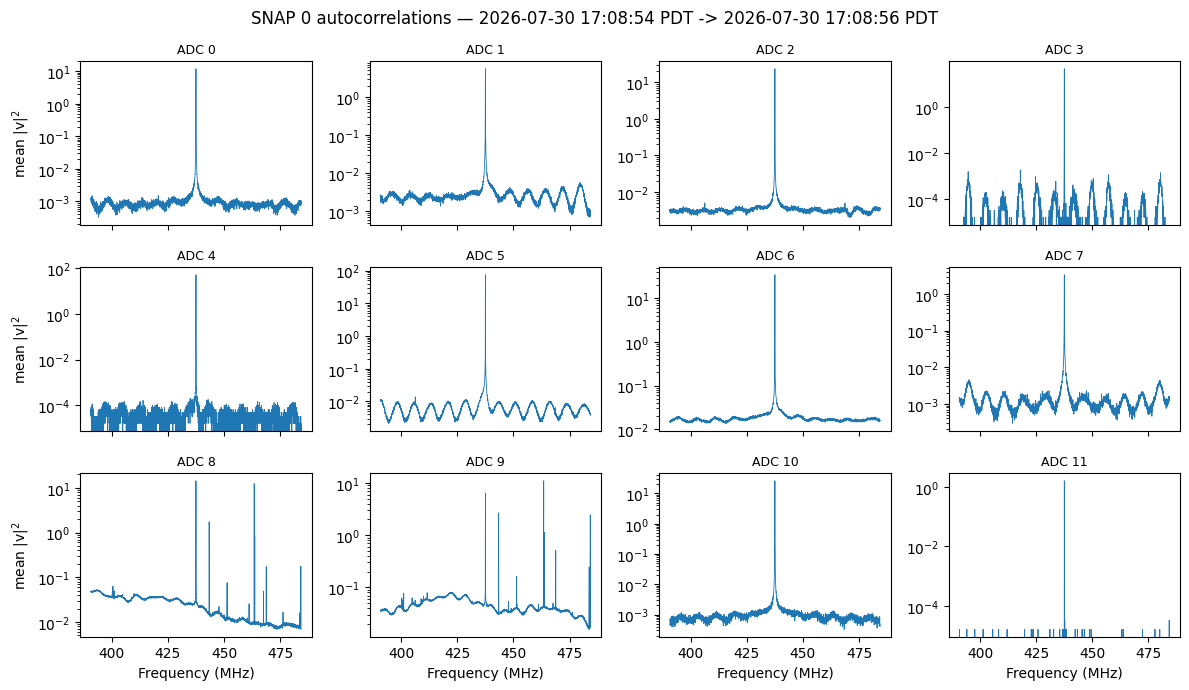

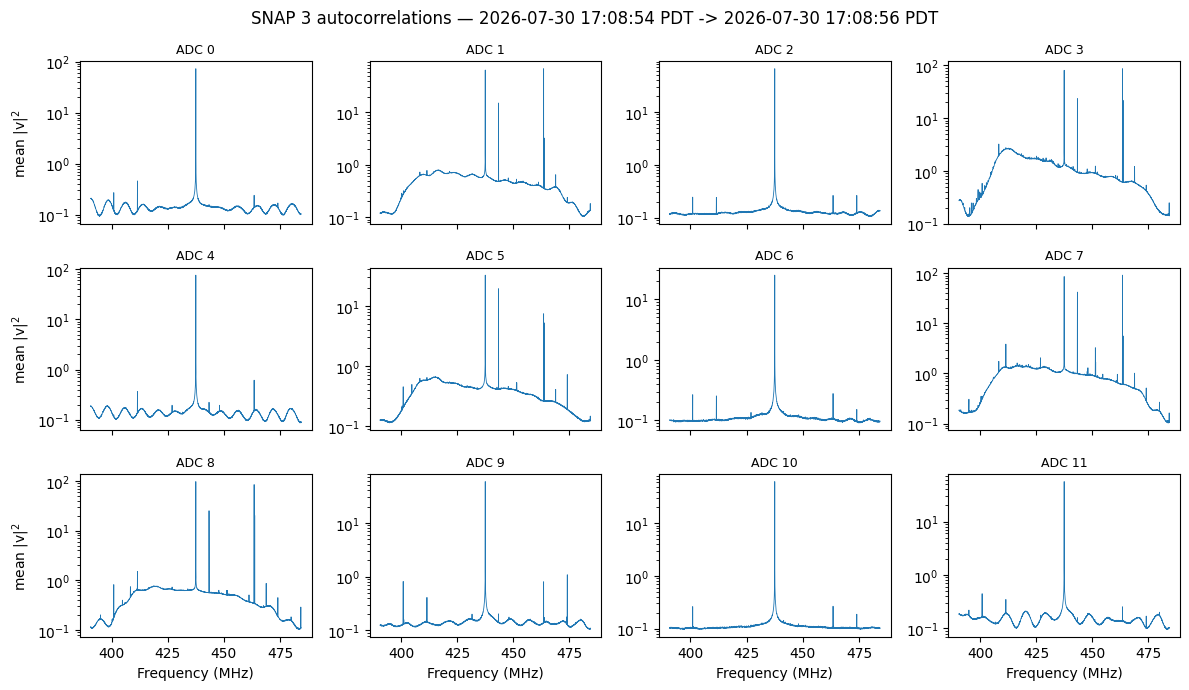

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
from casm_io.autocorr import psrdada_to_unix
from casm_io._time import format_time_span

t0 = psrdada_to_unix(header.get("DUMP_UTC_START", header["UTC_START"]))
when = format_time_span(t0, t0 + n * 32.768e-6, "America/Los_Angeles")

for snap in sorted(spec):
    fig, axes = plt.subplots(3, 4, figsize=(12, 7), sharex=True)
    for adc in range(spec[snap].shape[1]):
        ax = axes.flat[adc]
        ax.semilogy(freq, spec[snap][:, adc] / n, lw=0.6)
        ax.set_title(f"ADC {adc}", fontsize=9)
    for ax in axes[-1]:
        ax.set_xlabel("Frequency (MHz)")
    for ax in axes[:, 0]:
        ax.set_ylabel("mean |v|$^2$")
    fig.suptitle(f"SNAP {snap} autocorrelations — {when}")
    fig.tight_layout()

## 6. Cleaning up

Nothing deletes dumps automatically (the T3 janitor is off). When you are
done: remove your working directory, and the originals under
`/mnt/nvme4/data/casm/cand_dumps/stream_N/` on both nodes if nobody else
needs them. For batch work the same flow is scripted in
`examples/voltage_dumps.py`; `casm-autocorr` compares dump autocorrelations
against the correlator.